# TTM-R3 Zero-shot and Fine-tune examples

This notebooke demonstrates the usage of a pre-trained `TinyTimeMixer` model (R3) for several multivariate time series forecasting tasks. For details related to model architecture, refer to the [TTM paper](https://arxiv.org/pdf/2401.03955.pdf).

In this example, we will use a pre-trained TTM-2048-96 model. That means the TTM model can take an input of 2048 time points (`context_length`), and can forecast upto 96 time points (`forecast_length`) in the future. We will use the pre-trained TTM in two settings:
1. **Zero-shot**: The pre-trained TTM will be directly used to evaluate on the `test` split of the target data. Note that the TTM was NOT pre-trained on the target data.
2. **Few-shot**: The pre-trained TTM will be quickly fine-tuned on only 5% of the `train` split of the target data, and subsequently, evaluated on the `test` part of the target data.

Note: Alternatively, this notebook can be modified to try any other TTM model from a suite of TTM models. For details, visit the [Hugging Face TTM-R3 Model Repository](https://huggingface.co/ibm-research/ttm-r3).

1. IBM Granite TTM-R1 pre-trained models can be found here: [Granite-TTM-R1 Model Card](https://huggingface.co/ibm-granite/granite-timeseries-ttm-r1)
2. IBM Granite TTM-R2 pre-trained models can be found here: [Granite-TTM-R2 Model Card](https://huggingface.co/ibm-granite/granite-timeseries-ttm-r2)
3. Research-use (non-commercial use only) TTM-R2 pre-trained models can be found here: [Research-Use-TTM-R2](https://huggingface.co/ibm-research/ttm-research-r2)
4. Research-use (non-commercial use only) TTM-R3 pre-trained models can be found here: [Research-Use-TTM-R3](https://huggingface.co/ibm-research/ttm-r3)

## Imports

In [1]:
import math
import os
import tempfile

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK

from tsfm_public import TimeSeriesPreprocessor, TrackingCallback, count_parameters, get_datasets
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.lr_finder import optimal_lr_finder

In [3]:
import warnings


# Suppress all warnings
warnings.filterwarnings("ignore")

### Important arguments

In [4]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# TTM Model path. The default model path is Granite-R2. Below, you can choose other TTM releases.
TTM_MODEL_PATH = "ibm-research/ttm-r3"
# TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
# TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r1"
# TTM_MODEL_PATH = "ibm-research/ttm-research-r2"

# Context length, Or Length of the history.
# Currently supported values are: 512/1024/1536 for Granite-TTM-R2 and Research-Use-TTM-R2, and 512/1024 for Granite-TTM-R1
CONTEXT_LENGTH = 2048

# Granite-TTM-R2 supports forecast length upto 720 and Granite-TTM-R1 supports forecast length upto 96
PREDICTION_LENGTH = 96

# Results dir
OUT_DIR = "ttm_finetuned_models/"

# Data processing

In [5]:
# Dataset
TARGET_DATASET = "etth1"
dataset_path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
timestamp_column = "date"
id_columns = []  # mention the ids that uniquely identify a time-series.

target_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
split_config = {
    "train": [0, 8640],
    "valid": [8640, 11520],
    "test": [
        11520,
        14400,
    ],
}
# Understanding the split config -- slides

data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
}

## Zero-shot evaluation method

In [6]:
import inspect
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_predictions(
    model,
    dset,
    plot_dir,
    plot_prefix,
    indices=None,
    channel=0,
    plot_context=None,
    max_plots=10,
    figsize_per_plot=(12, 2.2),
):
    """
    Plot context, true future, median forecast, and 0.1-0.9 prediction interval.

    Expected model output:
        - prediction_outputs: [B, T_pred, C]
        - quantile_outputs:   [B, Q, T_pred, C]
    """

    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    if indices is None:
        n = min(max_plots, len(dset))
        indices = np.random.choice(len(dset), size=n, replace=False).tolist()
    else:
        indices = list(indices)

    if len(indices) == 0:
        raise ValueError("`indices` must contain at least one element.")

    device = next(model.parameters()).device
    signature_keys = set(inspect.signature(model.forward).parameters.keys())

    batch = {}
    sample0 = dset[indices[0]]
    for key in sample0.keys():
        if key in signature_keys:
            batch[key] = torch.stack([dset[i][key] for i in indices]).to(device)

    model_was_training = model.training
    model.eval()
    with torch.no_grad():
        outputs = model(**batch)
    if model_was_training:
        model.train()

    future = to_numpy(batch["future_values"])[:, :, channel]
    past = to_numpy(batch["past_values"])[:, :, channel]
    q_outputs = getattr(outputs, "quantile_outputs", None)

    if q_outputs is None:
        raise ValueError("This plotting function expects `quantile_outputs` in the model output.")

    q_outputs = to_numpy(q_outputs)[:, :, :, channel]  # [B, Q, T_pred]
    prediction_length = q_outputs.shape[-1]

    if plot_context is None:
        plot_context = min(4 * prediction_length, past.shape[1])

    quantile_levels = list(getattr(model.config, "quantile_levels", []))
    required_quantiles = [0.1, 0.5, 0.9]
    if not all(q in quantile_levels for q in required_quantiles):
        raise ValueError(
            f"Model quantiles must include {required_quantiles}. Found: {quantile_levels}"
        )

    low_idx = quantile_levels.index(0.1)
    med_idx = quantile_levels.index(0.5)
    high_idx = quantile_levels.index(0.9)

    plt.style.use("seaborn-v0_8-whitegrid")

    num_plots = len(indices)
    fig, axs = plt.subplots(
        num_plots,
        1,
        figsize=(figsize_per_plot[0], figsize_per_plot[1] * num_plots),
        sharex=False,
    )
    if num_plots == 1:
        axs = [axs]

    for i, ax in enumerate(axs):
        idx = indices[i]

        context = past[i, -plot_context:]
        true_future = future[i]
        median_forecast = q_outputs[i, med_idx]
        lower = q_outputs[i, low_idx]
        upper = q_outputs[i, high_idx]

        ts_y = np.arange(len(context))
        ts_y_hat = np.arange(len(context), len(context) + prediction_length)
        ts_y2 = ts_y_hat

        ax.plot(ts_y, context, label="Context", linestyle="-", color="black", linewidth=1.2)
        ax.plot(ts_y2, true_future, label="True future", linestyle="-", color="navy", linewidth=1.2)
        ax.plot(ts_y_hat, median_forecast, label="Median forecast", linestyle="--", color="orange", linewidth=1.2)
        ax.fill_between(
            ts_y_hat,
            lower,
            upper,
            label="Prediction interval",
            alpha=0.7,
            color="lightskyblue",
            linewidth=1,
        )

        ax.axvline(len(context) - 1, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"Example {idx}")
        ax.set_xlabel("Time step")
        ax.set_ylabel(f"Ch {channel}")
        ax.legend(loc="best", ncol=4, fontsize=9)

    plt.tight_layout()

    if plot_dir is not None:
        os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(os.path.join(plot_dir, f"{plot_prefix}_ch_{channel}.pdf"), bbox_inches="tight")
        plt.savefig(os.path.join(plot_dir, f"{plot_prefix}_ch_{channel}.png"), dpi=200, bbox_inches="tight")

    return fig, axs

In [7]:
def zeroshot_eval(dataset_name, batch_size, context_length=512, forecast_length=96):
    # Get data

    tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )

    # Load model
    zeroshot_model = get_model(
        TTM_MODEL_PATH,
        context_length=context_length,
        prediction_length=forecast_length,
        freq_prefix_tuning=False,
        freq=None,
        prefer_l1_loss=False,
        prefer_longer_context=True,
    )

    dset_train, dset_valid, dset_test = get_datasets(
        tsp, data, split_config, use_frequency_token=zeroshot_model.config.resolution_prefix_tuning
    )

    temp_dir = tempfile.mkdtemp()
    # zeroshot_trainer
    zeroshot_trainer = Trainer(
        model=zeroshot_model,
        args=TrainingArguments(
            output_dir=temp_dir,
            per_device_eval_batch_size=batch_size,
            seed=SEED,
            report_to="none",
        ),
    )
    # evaluate = zero-shot performance
    print("+" * 20, "Test MSE zero-shot", "+" * 20)
    zeroshot_output = zeroshot_trainer.evaluate(dset_test)
    print(zeroshot_output)

    # get predictions
    predictions_dict = zeroshot_trainer.predict(dset_test)

    predictions_np = predictions_dict.predictions[0]

    print(predictions_np.shape)

    # plot
    plot_predictions(
        model=zeroshot_trainer.model,
        dset=dset_test,
        plot_dir=os.path.join(OUT_DIR, dataset_name),
        plot_prefix="test_zeroshot",
        indices=[685, 118, 902, 1984, 894, 967, 304, 57, 265, 1015],
        channel=0,
    )


# Zeroshot

INFO:p-519246:t-23108718060224:get_model.py:get_model:Loading model from: ibm-research/ttm-r3
INFO:p-519246:t-23108718060224:get_model.py:get_model:Model path type is 4
INFO:p-519246:t-23108718060224:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-519246:t-23108718060224:get_model.py:get_model:Model path type is 2
INFO:p-519246:t-23108718060224:get_model.py:get_model:Would load from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-519246:t-23108718060224:get_model.py:get_model:Attempting model load from ibm-research/ttm-r3, revision = 2048-96-r3.
INFO:p-519246:t-23108718060224:get_model.py:get_model:Model loaded successfully from ibm-research/ttm-r3, revision = 2048-96-r3.
INFO:p-519246:t-23108718060224:get_model.py:get_model:[TTM] context_length = 2048, prediction_length = 96


++++++++++++++++++++ Test MSE zero-shot ++++++++++++++++++++


{'eval_loss': 0.8830724358558655, 'eval_model_preparation_time': 0.0043, 'eval_runtime': 8.7213, 'eval_samples_per_second': 319.333, 'eval_steps_per_second': 5.045}
(2785, 96, 7)


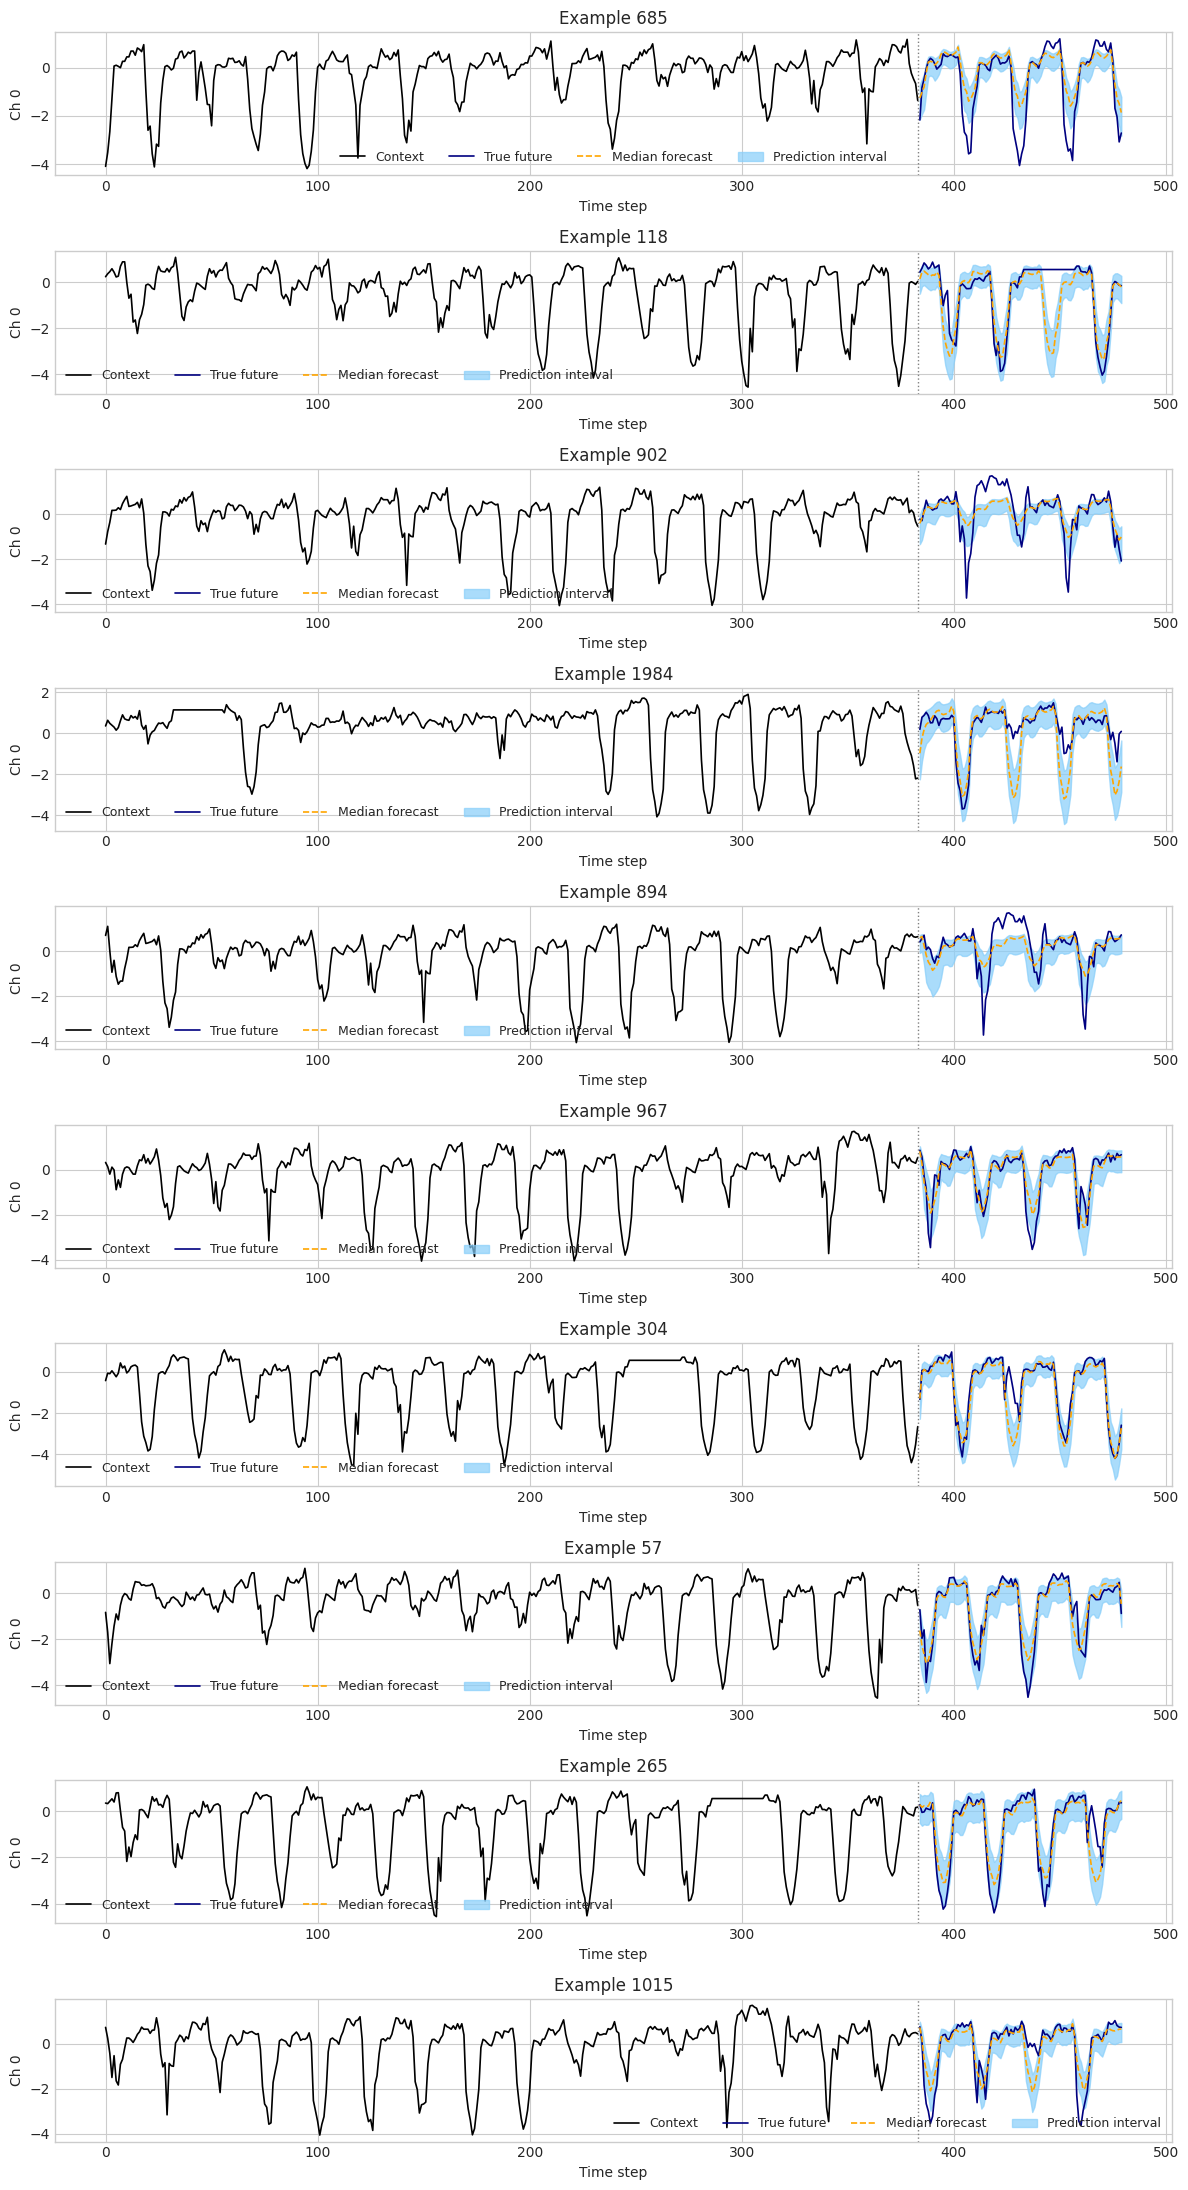

In [8]:
zeroshot_eval(
    dataset_name=TARGET_DATASET, context_length=CONTEXT_LENGTH, forecast_length=PREDICTION_LENGTH, batch_size=64
)

 ## Few-shot finetune and evaluation method

In [9]:
import torch.nn as nn
from tinytimemixer.full_benchmarking.gift_leaderboard_ttm_r3_nc.src.ttm_gluonts_predictor import enable_ft_ttm_grads

In [12]:
def fewshot_finetune_eval(
    dataset_name,
    batch_size,
    learning_rate=None,
    context_length=512,
    forecast_length=96,
    fewshot_percent=5,
    freeze_backbone=True,
    num_epochs=5,
    save_dir=OUT_DIR,
):
    out_dir = os.path.join(save_dir, dataset_name)

    print("-" * 20, f"Running few-shot {fewshot_percent}%", "-" * 20)

    # Data prep: Get dataset

    tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )

    # Get ttm model
    finetune_forecast_model = get_model(
        TTM_MODEL_PATH,
        context_length=context_length,
        prediction_length=forecast_length,
        freq="H",
        use_lite=False,
        # Can also provide TTM Config args as well
        head_dropout=0.7,
    )

    # Get datasets
    dset_train, dset_val, dset_test = get_datasets(
        tsp,
        data,
        split_config,
        fewshot_fraction=fewshot_percent / 100,
        fewshot_location="first",
        use_frequency_token=finetune_forecast_model.config.resolution_prefix_tuning,
    )

    # Various TTM R3 components can be frozen during finetuning
    enable_ft_ttm_grads(
        finetune_forecast_model,
        patch_tune=False,
        bias_tune=True,
        norm_tune=True,
        backbone_tune=False,
        prefix_tune=False,
        decoder_tune=False,
        head_tune=False,
        quantile_tune=False,
    )

    # Find optimal learning rate
    # Use with caution: Set it manually if the suggested learning rate is not suitable
    if learning_rate is None:
        learning_rate, finetune_forecast_model = optimal_lr_finder(
            finetune_forecast_model,
            dset_train,
            batch_size=batch_size,
        )
        print("OPTIMAL SUGGESTED LEARNING RATE =", learning_rate)

    print(f"Using learning rate = {learning_rate}")
    finetune_forecast_args = TrainingArguments(
        output_dir=os.path.join(out_dir, "output"),
        overwrite_output_dir=True,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        do_eval=True,
        eval_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=8,
        report_to="none",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        logging_dir=os.path.join(out_dir, "logs"),  # Make sure to specify a logging directory
        load_best_model_at_end=True,  # Load the best model when training ends
        metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
        greater_is_better=False,  # For loss
        seed=SEED,
    )

    # Create the early stopping callback
    early_stopping_callback = EarlyStoppingCallback(
        early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
        early_stopping_threshold=1e-5,  # Minimum improvement required to consider as improvement
    )
    tracking_callback = TrackingCallback()

    # Optimizer and scheduler
    optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
    scheduler = OneCycleLR(
        optimizer,
        learning_rate,
        epochs=num_epochs,
        steps_per_epoch=math.ceil(len(dset_train) / (batch_size)),
    )

    finetune_forecast_trainer = Trainer(
        model=finetune_forecast_model,
        args=finetune_forecast_args,
        train_dataset=dset_train,
        eval_dataset=dset_val,
        callbacks=[early_stopping_callback, tracking_callback],
        optimizers=(optimizer, scheduler),
    )
    finetune_forecast_trainer.remove_callback(INTEGRATION_TO_CALLBACK["codecarbon"])

    # Fine tune
    finetune_forecast_trainer.train()

    # Evaluation
    print("+" * 20, f"Test MSE after few-shot {fewshot_percent}% fine-tuning", "+" * 20)


    fewshot_output = finetune_forecast_trainer.evaluate(dset_test)
    print(fewshot_output)
    print("+" * 60)

    # get predictions
    predictions_dict = finetune_forecast_trainer.predict(dset_test)

    predictions_np = predictions_dict.predictions[0]

    print(predictions_np.shape)

    # plot
    plot_predictions(
        model=finetune_forecast_trainer.model,
        dset=dset_test,
        plot_dir=os.path.join(OUT_DIR, dataset_name),
        plot_prefix="test_fewshot",
        indices=[685, 118, 902, 1984, 894, 967, 304, 57, 265, 1015],
        channel=0,
    )

### Few-shot 5%

INFO:p-519246:t-23108718060224:get_model.py:get_model:Loading model from: ibm-research/ttm-r3
INFO:p-519246:t-23108718060224:get_model.py:get_model:Model path type is 4
INFO:p-519246:t-23108718060224:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-519246:t-23108718060224:get_model.py:get_model:Model path type is 2
INFO:p-519246:t-23108718060224:get_model.py:get_model:Would load from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-519246:t-23108718060224:get_model.py:get_model:Attempting model load from ibm-research/ttm-r3, revision = 2048-96-r3.


-------------------- Running few-shot 5% --------------------


INFO:p-519246:t-23108718060224:get_model.py:get_model:Model loaded successfully from ibm-research/ttm-r3, revision = 2048-96-r3.
INFO:p-519246:t-23108718060224:get_model.py:get_model:[TTM] context_length = 2048, prediction_length = 96
INFO:p-519246:t-23108718060224:lr_finder.py:optimal_lr_finder:LR Finder: Running learning rate (LR) finder algorithm. If the suggested LR is very low, we suggest setting the LR manually.
INFO:p-519246:t-23108718060224:lr_finder.py:optimal_lr_finder:LR Finder: Using cuda:0.
INFO:p-519246:t-23108718060224:lr_finder.py:optimal_lr_finder:LR Finder: Suggested learning rate = 0.0009111627561154895


OPTIMAL SUGGESTED LEARNING RATE = 0.0009111627561154895
Using learning rate = 0.0009111627561154895


Epoch,Training Loss,Validation Loss
1,0.907500,1.212471
2,0.858900,1.221430
3,0.818800,1.239669
4,0.792500,1.251523
5,0.783100,1.253352


[TrackingCallback] Mean Epoch Time = 1.7889609813690186 seconds, Total Train Time = 44.818647146224976
++++++++++++++++++++ Test MSE after few-shot 5% fine-tuning ++++++++++++++++++++


{'eval_loss': 0.8819329142570496, 'eval_runtime': 6.9064, 'eval_samples_per_second': 403.248, 'eval_steps_per_second': 6.371, 'epoch': 5.0}
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
(2785, 96, 7)


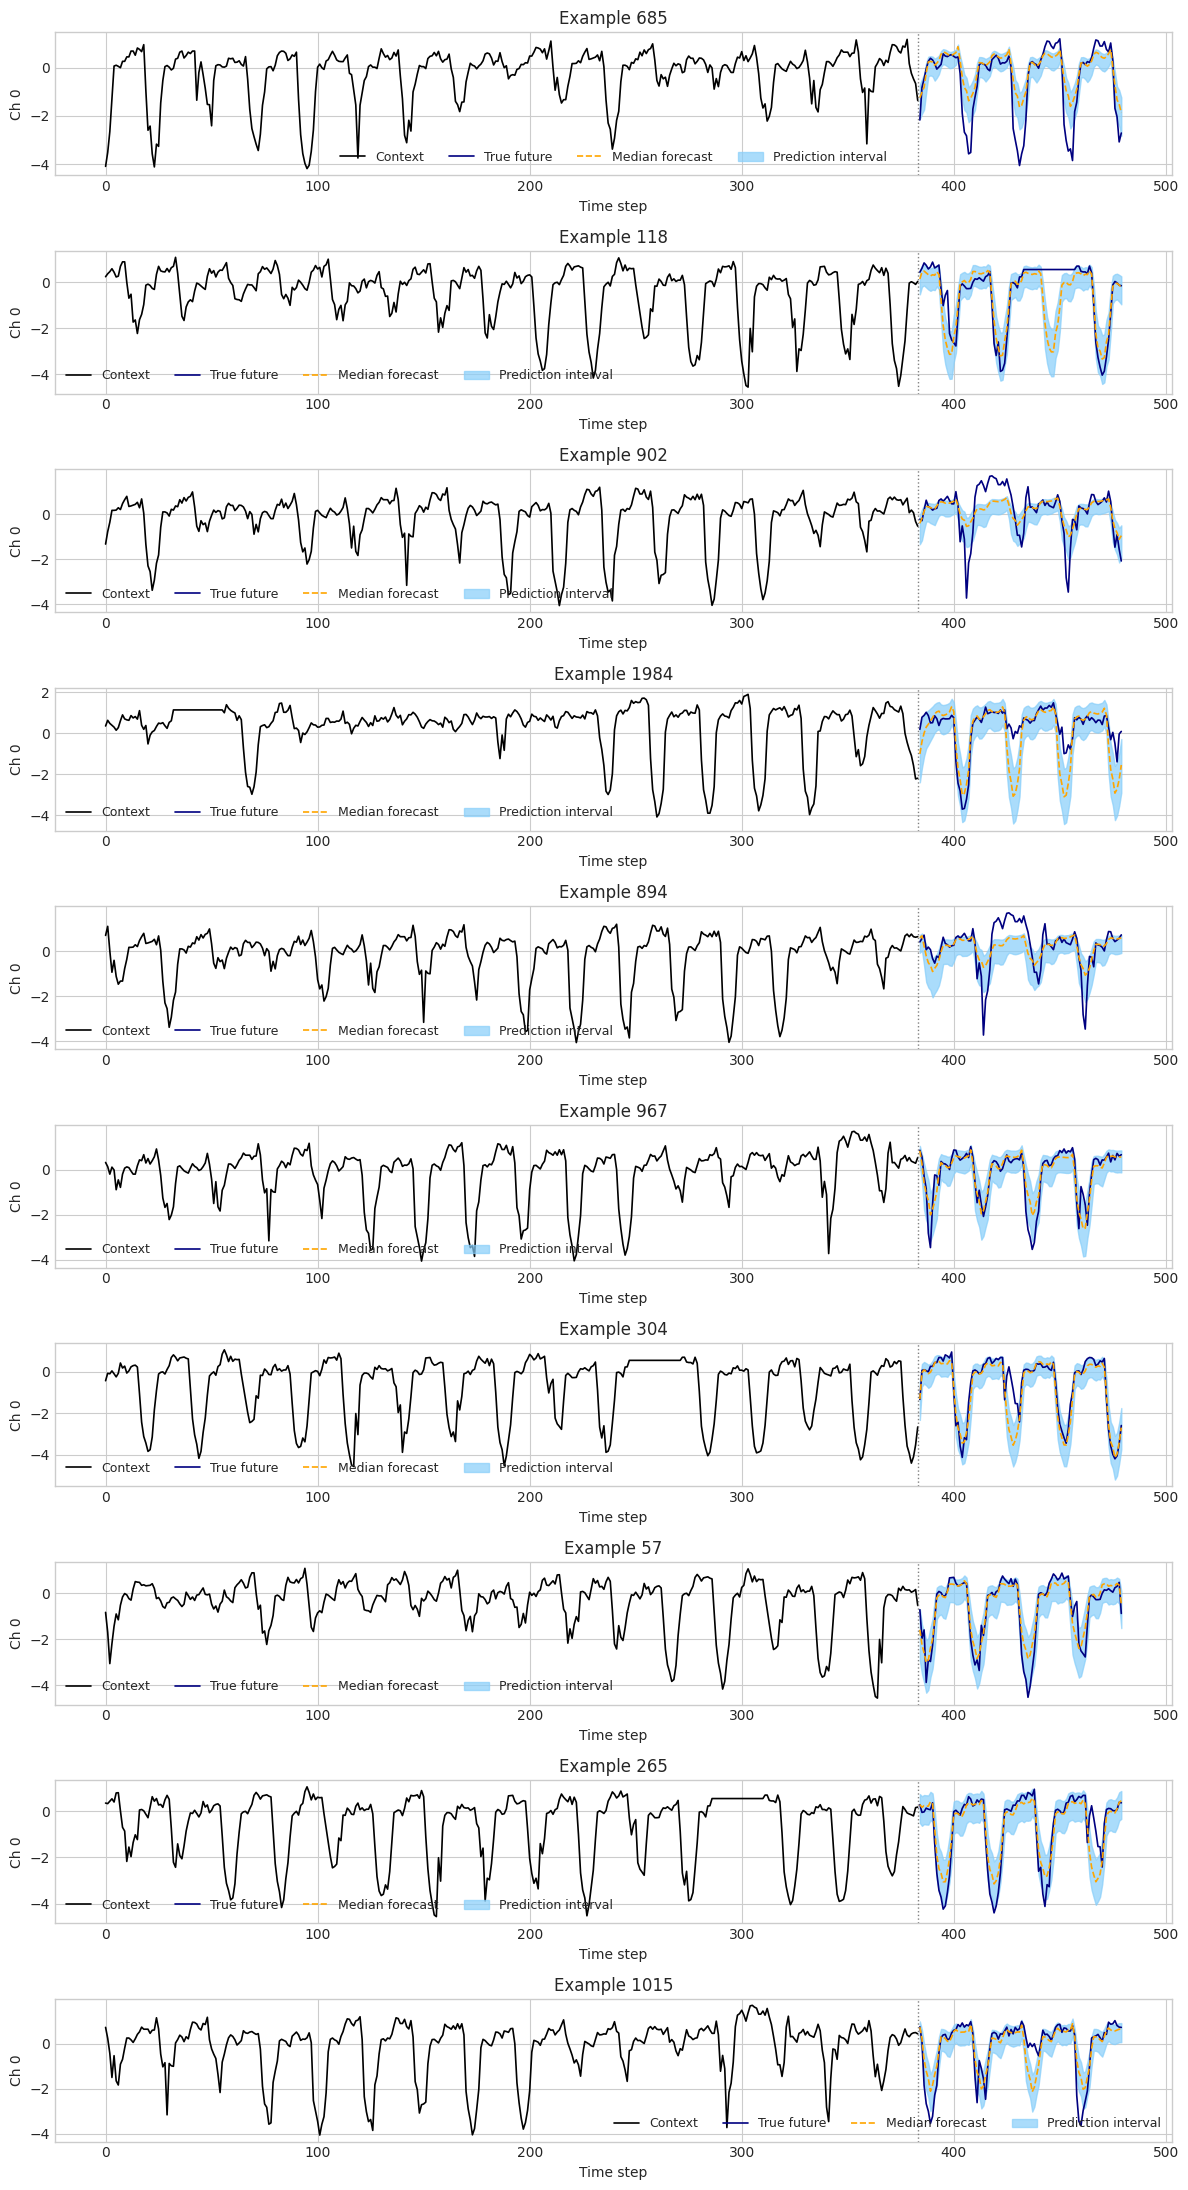

In [13]:
fewshot_finetune_eval(
    dataset_name=TARGET_DATASET,
    context_length=CONTEXT_LENGTH,
    forecast_length=PREDICTION_LENGTH,
    batch_size=64,
    fewshot_percent=5,
    learning_rate=None,
)